# Visualizing the Titanic Disaster

### Import the necessary libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

 ### See the first 5 entries

In [3]:
titanic = pd.read_csv('titanic.csv')

In [4]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###  What is the number of observations in the dataset?

In [5]:
observations = len(titanic)
observations

891

In [6]:
titanic.shape

(891, 12)

###  What is the number of columns in the dataset?

In [7]:
len(titanic.columns)

12

In [8]:
titanic.shape[1]

12

### Print the name of all the columns.

In [9]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
for column in titanic.columns:
    print(column)

PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked


### What is the name of 105th passenger?

In [11]:
person_105 = titanic[titanic['PassengerId'] ==106]
name_105 = person_105['Name']
print(name_105)

105    Mionoff, Mr. Stoytcho
Name: Name, dtype: object


In [12]:
titanic.iloc[105]['Name']

'Mionoff, Mr. Stoytcho'

### Set PassengerId as the index 

In [13]:
titanic.set_index('PassengerId', inplace=True)

In [14]:
print(titanic.index.name)

PassengerId


### Create a pie chart presenting the male/female proportion

In [15]:
row_count = titanic.Sex.value_counts()  #Raw counts of each
print(row_count)

Sex
male      577
female    314
Name: count, dtype: int64


In [16]:
proportion= titanic.Sex.value_counts(normalize=True)  #Calculates proportions/percentages
print(proportion)


Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64


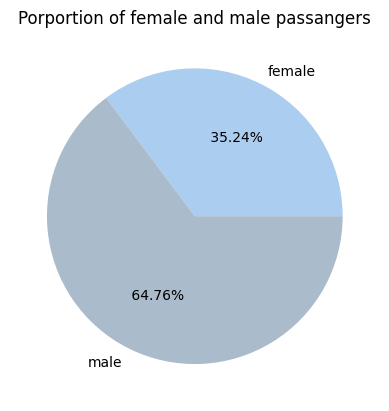

In [17]:
labels = 'female','male'
female_porp = titanic.Sex.value_counts(normalize=True)['female']
male_porp = titanic.Sex.value_counts(normalize=True)['male']
colors = ['#abcdef','#aabbcc']
plt.pie([female_porp,male_porp], labels= labels , colors=colors ,autopct='% .2f%%')
plt.title('Porportion of female and male passangers')
plt.show()


### Create a scatterplot with the Fare payed and the Age, differ the plot color by gender

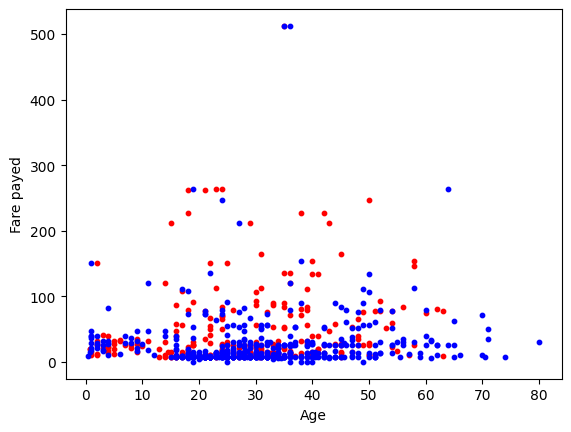

In [18]:

plt.ylabel('Fare payed')
plt.xlabel('Age')
female_passangers = titanic[titanic.Sex == 'female']
male_passangers = titanic[titanic.Sex == 'male']
plt.scatter(female_passangers.Age,female_passangers.Fare, color = 'red', s = 10)
plt.scatter(male_passangers.Age,male_passangers.Fare, color = 'blue', s = 10)
plt.show()

### How many people survived?

In [19]:
survived = titanic.Survived.value_counts()
print(survived[1])

342


### Create a histogram and box plot with the Fare payed (use subplot)

In [20]:
titanic

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


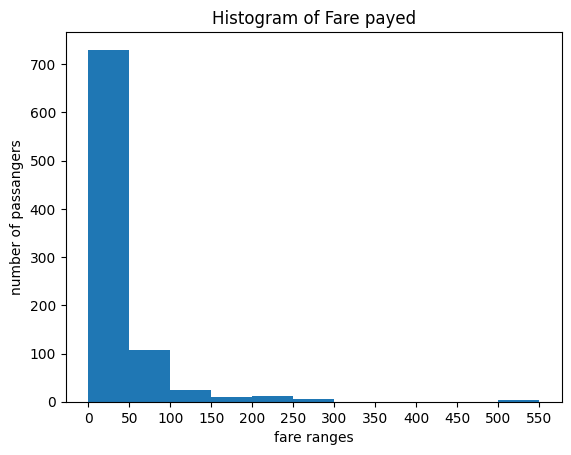

In [21]:
bins = np.arange(0,600,50)
plt.hist(titanic['Fare'],  bins=bins )
plt.xticks(bins)
plt.xlabel('fare ranges')
plt.ylabel('number of passangers')
plt.title('Histogram of Fare payed')
plt.show()

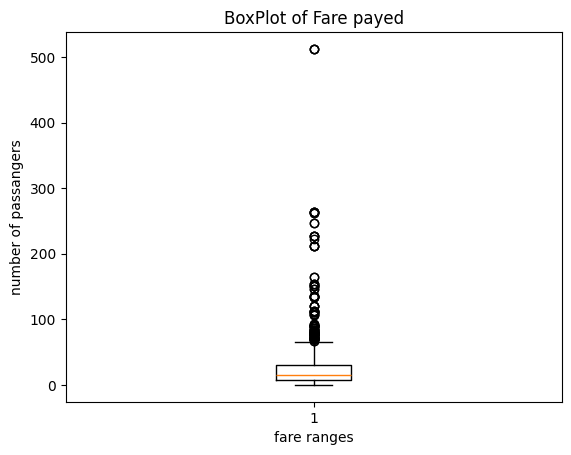

In [22]:
plt.boxplot([titanic.Fare])
plt.xlabel('fare ranges')
plt.ylabel('number of passangers')
plt.title('BoxPlot of Fare payed')
plt.show()

### Drop passengerID and Ticket columns

In [29]:
titanic.reset_index(inplace=True)
dropped = titanic.drop(['PassengerId', 'Ticket'], axis=1)

,level_0,index,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,2,2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,3,3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,4,4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,NaN,S
887,887,887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,B42,S
888,888,888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,NaN,S
889,889,889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C148,C


### Is there a meaningful relationship between living and dying with age? (show relationship by visual representation)

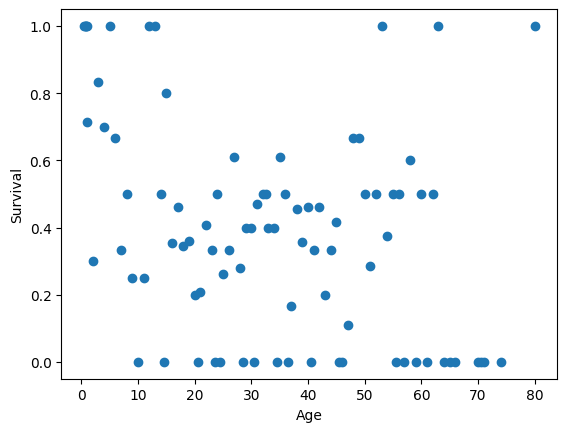

In [53]:
age_survival = titanic.groupby('Age')['Survived'].mean().reset_index()
plt.scatter(x='Age', y='Survived', data=age_survival)
plt.xlabel('Age')
plt.ylabel('Survival')
plt.show()


#with reset_index > 'Age' becomes a column (no longer an index)

### Tell me about the relationship between the age, Pclass and sex